In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amithgowdar/pinn-file-git/train_notebook.ipynb
/kaggle/input/datasets/amithgowdar/pinn-file-git/README.md
/kaggle/input/datasets/amithgowdar/pinn-file-git/losses/standard.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/utils/plot.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/conditions/boundary/dirichlet_zero.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/conditions/initial/burgers_ic.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/experiment/rar_pinn_burger.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/experiment/base_pinn.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/models/activation.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/models/sequential.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/experiments/spectral_bias
/kaggle/input/datasets/amithgowdar/pinn-file-git/data/burgers_data.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/data/rar_resample.py
/kaggle/input/datasets/amithgowdar/pinn-file-git/data/raw/burger

In [4]:
import sys
sys.path.append('/kaggle/input/datasets/amithgowdar/pinn-file-git')


In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/amithgowdar
/kaggle/input/datasets/amithgowdar/pinn-file-git
/kaggle/input/datasets/amithgowdar/pinn-file-git/losses
/kaggle/input/datasets/amithgowdar/pinn-file-git/utils
/kaggle/input/datasets/amithgowdar/pinn-file-git/conditions
/kaggle/input/datasets/amithgowdar/pinn-file-git/conditions/boundary
/kaggle/input/datasets/amithgowdar/pinn-file-git/conditions/initial
/kaggle/input/datasets/amithgowdar/pinn-file-git/experiment
/kaggle/input/datasets/amithgowdar/pinn-file-git/models
/kaggle/input/datasets/amithgowdar/pinn-file-git/experiments
/kaggle/input/datasets/amithgowdar/pinn-file-git/data
/kaggle/input/datasets/amithgowdar/pinn-file-git/data/raw
/kaggle/input/datasets/amithgowdar/pinn-file-git/equations


In [4]:
import torch
import json
from pathlib import Path

from models.sequential import MLP
from equations.burgers_eq import BurgersEquation
from conditions.initial.burgers_ic import BurgersIC
from conditions.boundary.dirichlet_zero import DirichletZeroBC
from losses.standard import StandardLoss
from data.burgers_data import load_training_data


def train(config: dict) -> dict:
    """
    Baseline PINN training loop for Burgers' equation.

    Args:
        config: dict with keys —
            layers      : e.g. [2, 64, 64, 64, 1]
            activation  : "tanh" | "swish" | "sine" | ...
            nu          : viscosity (default 0.01/pi)
            N_ic, N_bc, N_pde : collocation counts
            n_epochs    : training iterations
            lr          : Adam learning rate
            lambda_ic, lambda_bc, lambda_pde : loss weights
            log_every   : print interval
            save_dir    : where to write history JSON

    Returns:
        history dict with lists: "ic", "bc", "pde", "total"
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # --- Model ---
    model = MLP(
        layers=config["layers"],
        activation=config.get("activation", "tanh")
    ).to(device)

    # --- Equation, IC, BC, Loss ---
    equation = BurgersEquation(nu=config.get("nu", 0.01 / 3.141592653589793))
    ic       = BurgersIC()
    bc       = DirichletZeroBC()
    loss_fn  = StandardLoss(
        lambda_ic  = config.get("lambda_ic",  1.0),
        lambda_bc  = config.get("lambda_bc",  1.0),
        lambda_pde = config.get("lambda_pde", 1.0),
    )

    # --- Data (static batch — full collocation set) ---
    batch = load_training_data(
        N_ic  = config.get("N_ic",  100),
        N_bc  = config.get("N_bc",  100),
        N_pde = config.get("N_pde", 10000),
    )
    # Move to device
    batch = {k: v.to(device) for k, v in batch.items()}

    # --- Optimiser ---
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get("lr", 1e-3))

    # --- History ---
    history = {"ic": [], "bc": [], "pde": [], "total": []}

    n_epochs  = config.get("n_epochs", 10000)
    log_every = config.get("log_every", 500)

    # --- Training loop ---
    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()

        losses = loss_fn.compute(equation, ic, bc, model, batch)
        losses["total"].backward()
        optimizer.step()

        # Log scalar values — detach before storing
        for key in history:
            history[key].append(losses[key].item())

        if epoch % log_every == 0:
            print(
                f"Epoch {epoch:>6d} | "
                f"Total {losses['total'].item():.4e} | "
                f"IC {losses['ic'].item():.4e} | "
                f"BC {losses['bc'].item():.4e} | "
                f"PDE {losses['pde'].item():.4e}"
            )

    # --- Save history and model ---
    save_dir = Path(config.get("save_dir", "experiments/spectral_bias"))
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "history.json", "w") as f:
        json.dump(history, f)

    torch.save(model.state_dict(), save_dir / "model.pt")
    print(f"\nSaved → {save_dir}/history.json  and  model.pt")

    return history, model


# ---------------------------------------------------------------------------
# Default config — edit here or override by passing a dict to train()
# ---------------------------------------------------------------------------
DEFAULT_CONFIG = {
    "layers":      [2, 64, 64, 64, 1],
    "activation":  "tanh",
    "nu":          0.01 / 3.141592653589793,
    "N_ic":        100,
    "N_bc":        100,
    "N_pde":       10000,
    "n_epochs":    10000,
    "lr":          1e-3,
    "lambda_ic":   1.0,
    "lambda_bc":   1.0,
    "lambda_pde":  1.0,
    "log_every":   500,
    "save_dir":    "experiments/spectral_bias",
}

if __name__ == "__main__":
    train(DEFAULT_CONFIG)

Device: cpu
Epoch    500 | Total 8.1927e-02 | IC 4.9242e-02 | BC 4.4734e-04 | PDE 3.2237e-02
Epoch   1000 | Total 6.3259e-02 | IC 4.0876e-02 | BC 7.9857e-05 | PDE 2.2304e-02
Epoch   1500 | Total 4.5718e-02 | IC 2.8604e-02 | BC 3.3553e-05 | PDE 1.7080e-02
Epoch   2000 | Total 2.6699e-02 | IC 1.5350e-02 | BC 1.6459e-05 | PDE 1.1332e-02
Epoch   2500 | Total 1.4321e-02 | IC 7.8587e-03 | BC 1.0559e-05 | PDE 6.4514e-03
Epoch   3000 | Total 9.2322e-03 | IC 4.9346e-03 | BC 7.4302e-06 | PDE 4.2902e-03
Epoch   3500 | Total 6.7189e-03 | IC 3.5752e-03 | BC 4.8072e-06 | PDE 3.1389e-03
Epoch   4000 | Total 4.7846e-03 | IC 2.5834e-03 | BC 5.8216e-06 | PDE 2.1954e-03
Epoch   4500 | Total 2.7813e-03 | IC 1.4393e-03 | BC 5.1592e-06 | PDE 1.3369e-03
Epoch   5000 | Total 1.7807e-03 | IC 9.2075e-04 | BC 4.0531e-06 | PDE 8.5587e-04
Epoch   5500 | Total 1.2596e-03 | IC 6.4078e-04 | BC 2.9925e-06 | PDE 6.1586e-04
Epoch   6000 | Total 9.6924e-04 | IC 4.7680e-04 | BC 2.4976e-06 | PDE 4.8994e-04
Epoch   6500 | T

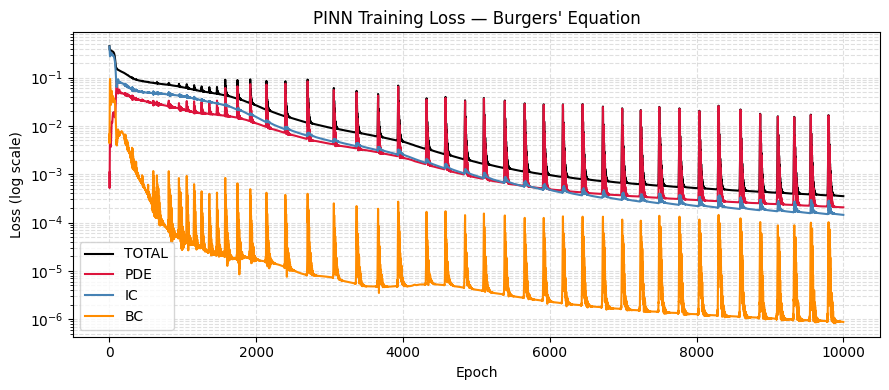

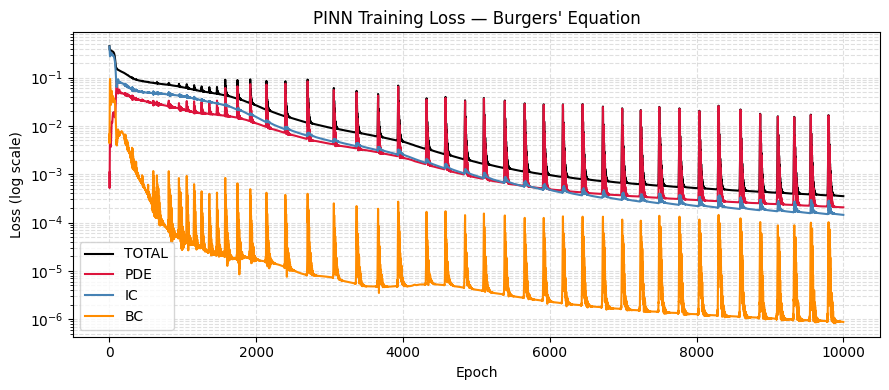

In [8]:
from utils.plot import plot_loss_curves
import json
history_path = "/kaggle/working/experiments/spectral_bias/history.json"
with open(history_path, "r") as f:
    history = json.load(f)

plot_loss_curves(history)

In [6]:
import torch
import json
from pathlib import Path

from models.sequential         import MLP
from equations.burgers_eq      import BurgersEquation
from conditions.initial.burgers_ic   import BurgersIC
from conditions.boundary.dirichlet_zero import DirichletZeroBC
from losses.standard           import StandardLoss
from data.burgers_data         import load_training_data
from data.rar_resample         import rar_resample


def train(config: dict) -> dict:
    """
    Baseline PINN training loop for Burgers' equation.

    Args:
        config: dict with keys —
            layers      : e.g. [2, 64, 64, 64, 1]
            activation  : "tanh" | "swish" | "sine" | ...
            nu          : viscosity (default 0.01/pi)
            N_ic, N_bc, N_pde : collocation counts
            n_epochs    : training iterations
            lr          : Adam learning rate
            lambda_ic, lambda_bc, lambda_pde : loss weights
            log_every   : print interval
            save_dir    : where to write history JSON

    Returns:
        history dict with lists: "ic", "bc", "pde", "total"
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # --- Model ---
    model = MLP(
        layers=config["layers"],
        activation=config.get("activation", "tanh")
    ).to(device)

    # --- Equation, IC, BC, Loss ---
    equation = BurgersEquation(nu=config.get("nu", 0.01 / 3.141592653589793))
    ic       = BurgersIC()
    bc       = DirichletZeroBC()
    loss_fn  = StandardLoss(
        lambda_ic  = config.get("lambda_ic",  1.0),
        lambda_bc  = config.get("lambda_bc",  1.0),
        lambda_pde = config.get("lambda_pde", 1.0),
    )

    # --- Data (static batch — full collocation set) ---
    batch = load_training_data(
        N_ic  = config.get("N_ic",  100),
        N_bc  = config.get("N_bc",  100),
        N_pde = config.get("N_pde", 10000),
    )
    # Move to device
    batch = {k: v.to(device) for k, v in batch.items()}

    # --- Optimiser ---
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get("lr", 1e-3))

    # --- History ---
    history = {"ic": [], "bc": [], "pde": [], "total": [], "n_pde_points": []}

    n_epochs  = config.get("n_epochs", 10000)
    log_every = config.get("log_every", 500)

    # --- RAR config ---
    use_rar       = config.get("use_rar", False)
    rar_every     = config.get("rar_every", 1000)
    rar_k         = config.get("rar_k", 100)
    rar_n_cand    = config.get("rar_n_candidates", 100000)

    # --- Training loop ---
    for epoch in range(1, n_epochs + 1):

        # RAR resampling — guarded, runs every `rar_every` epochs, never on epoch 0
        if use_rar and epoch % rar_every == 0:
            new_x_pde, new_t_pde = rar_resample(
                model      = model,
                equation   = equation,
                x_pde      = batch["x_pde"],
                t_pde      = batch["t_pde"],
                k          = rar_k,
                n_candidates = rar_n_cand,
                device     = device,
            )
            batch["x_pde"] = new_x_pde
            batch["t_pde"] = new_t_pde
            print(f"  [RAR] epoch {epoch}: added {rar_k} points → "
                  f"x_pde now has {batch['x_pde'].shape[0]} points")

        optimizer.zero_grad()

        losses = loss_fn.compute(equation, ic, bc, model, batch)
        losses["total"].backward()
        optimizer.step()

        # Log scalar values — detach before storing
        for key in ["ic", "bc", "pde", "total"]:
            history[key].append(losses[key].item())
        history["n_pde_points"].append(batch["x_pde"].shape[0])

        if epoch % log_every == 0:
            print(
                f"Epoch {epoch:>6d} | "
                f"Total {losses['total'].item():.4e} | "
                f"IC {losses['ic'].item():.4e} | "
                f"BC {losses['bc'].item():.4e} | "
                f"PDE {losses['pde'].item():.4e} | "
                f"N_pde {batch['x_pde'].shape[0]}"
            )

    # --- Save history and model ---
    save_dir = Path(config.get("save_dir", "experiments/spectral_bias"))
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "history.json", "w") as f:
        json.dump(history, f)

    torch.save(model.state_dict(), save_dir / "model.pt")
    print(f"\nSaved → {save_dir}/history.json  and  model.pt")

    return history, model


# ---------------------------------------------------------------------------
# Default config — edit here or override by passing a dict to train()
# ---------------------------------------------------------------------------
DEFAULT_CONFIG = {
    "layers":      [2, 64, 64, 64, 1],
    "activation":  "tanh",
    "nu":          0.01 / 3.141592653589793,
    "N_ic":        100,
    "N_bc":        100,
    "N_pde":       10000,
    "n_epochs":    10000,
    "lr":          1e-3,
    "lambda_ic":   1.0,
    "lambda_bc":   1.0,
    "lambda_pde":  1.0,
    "log_every":   500,
    "save_dir":    "experiments/spectral_bias",
    "use_rar":         False,   # baseline — set True for the RAR experiment
    "rar_every":       1000,    # Lu et al. 2021
    "rar_k":           100,     # Lu et al. 2021 default
    "rar_n_candidates": 100000,
}

RAR_CONFIG = {
    **DEFAULT_CONFIG,
    "use_rar":  True,
    "save_dir": "experiments/rar",
}

if __name__ == "__main__":
    train(DEFAULT_CONFIG)

Device: cpu
Epoch    500 | Total 8.7796e-02 | IC 5.0497e-02 | BC 1.1032e-03 | PDE 3.6195e-02 | N_pde 10000
Epoch   1000 | Total 7.1676e-02 | IC 4.4648e-02 | BC 5.0413e-04 | PDE 2.6524e-02 | N_pde 10000
Epoch   1500 | Total 4.2975e-02 | IC 2.4864e-02 | BC 2.7312e-04 | PDE 1.7838e-02 | N_pde 10000
Epoch   2000 | Total 2.5297e-02 | IC 1.3050e-02 | BC 2.6070e-04 | PDE 1.1986e-02 | N_pde 10000
Epoch   2500 | Total 1.7981e-02 | IC 9.3669e-03 | BC 1.8642e-04 | PDE 8.4279e-03 | N_pde 10000
Epoch   3000 | Total 1.3103e-02 | IC 6.6189e-03 | BC 1.4880e-04 | PDE 6.3357e-03 | N_pde 10000
Epoch   3500 | Total 1.0636e-02 | IC 5.2665e-03 | BC 1.3245e-04 | PDE 5.2366e-03 | N_pde 10000
Epoch   4000 | Total 7.4014e-03 | IC 3.5107e-03 | BC 9.1556e-05 | PDE 3.7992e-03 | N_pde 10000
Epoch   4500 | Total 6.0973e-03 | IC 2.9961e-03 | BC 6.7765e-05 | PDE 3.0334e-03 | N_pde 10000
Epoch   5000 | Total 6.5993e-03 | IC 2.1994e-03 | BC 5.8048e-05 | PDE 4.3418e-03 | N_pde 10000
Epoch   5500 | Total 3.9825e-03 | IC 1

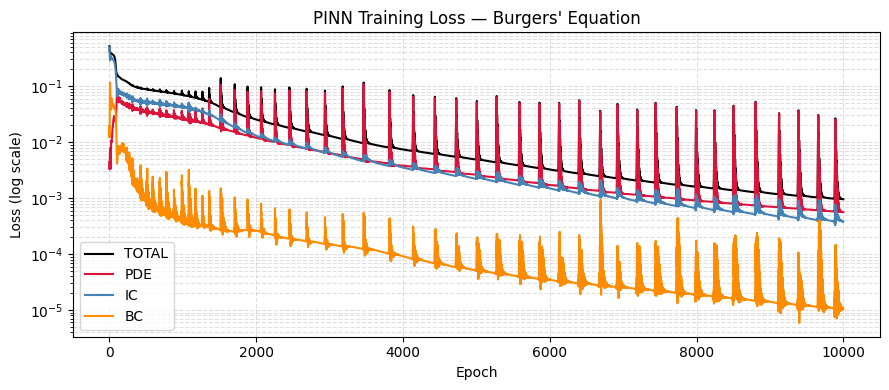

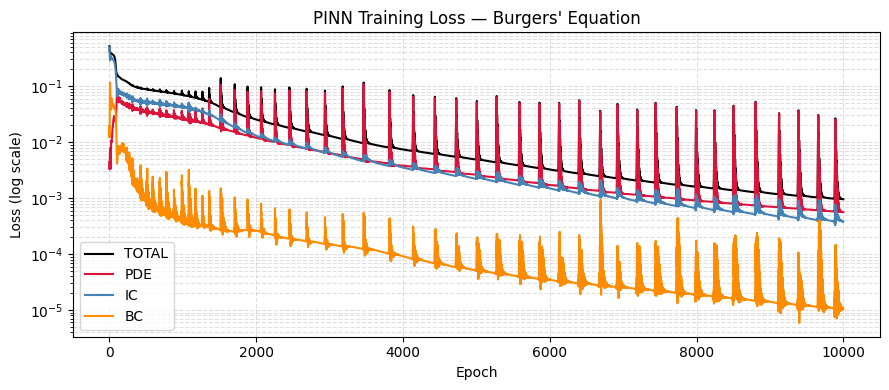

In [7]:
from utils.plot import plot_loss_curves
import json
history_path = "/kaggle/working/experiments/spectral_bias/history.json"
with open(history_path, "r") as f:
    history = json.load(f)

plot_loss_curves(history) 